# Seattle気象データ：季節性と観測期間内の変動

run_id: `v020-exp-26`。Kaggleの公開検索から対応CSVを取得し、取得に失敗した場合にだけ指定の旧実験CSVを使う。API認証情報は表示・保存しない。

## 分析計画（結果を見る前）
1. 取得版・SHA-256・列の単位・日付範囲を確定し、欠測日、重複、範囲、最高最低気温の整合性を確認する。
2. 月別の最高/最低気温平均と日々の分布、月別降水量平均・年別線・雨日の頻度を図表で比較する。降水は日数で正規化した値も示す。
3. 暦年の気温平均・降水総量・最大日降水量を記述し、長期的な気候傾向や因果効果には拡張しない。
4. 年を一つずつ除いた分析、平均と中央値、雨日閾値、上位降水日の寄与を使って結論の安定性を評価する。
5. 初回結果を読み直し、結論を変え得る未解決点に対して最大3回の追加依頼を記録・実行する。最後に全コードセルを上から再実行し、視覚監査とライフサイクル状態を確認する。

## 実行・保存方式
分析はJupyter MCPのネイティブ `execute_cell` で実行する。Notebookの作成・編集・根拠付きInsightの追記は別の制御Notebookから `project_manager.ensure_notebook/enqueue_write` で行う。実行中Notebookの自己書込みとMCP側保存の競合を避ける。`mcp_gateway.run_and_record` はネイティブMCPツールにPythonのMCPClientハンドルが渡されないため直接利用せず、使用済みモジュールに含めない。端末・subprocess・外部スクリプト・作業エージェントは使用しない。


In [3]:
from pathlib import Path
import sys, os, json, hashlib, io, contextlib, logging, inspect, zipfile
from datetime import datetime, timezone
from dataclasses import asdict
REPO = Path('/home/nahisaho/GitHub/jupytermind')
sys.path.insert(0, str(REPO / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(REPO / 'benchmark/projects')
import numpy as np
import pandas as pd
import nbformat
from IPython.display import display, Image
from ai_data_scientist import project_manager as pm, lifecycle, language_router
from ai_data_scientist.ingestion import ingest, SourceSpec
from ai_data_scientist.cleaning import clean_dataset
from ai_data_scientist.eda import explore
from ai_data_scientist.data_definition import FieldValue, build_manifest
from ai_data_scientist.analysis_assumptions import Assumption, AnalysisAssumptionManifest, check_manifest
from ai_data_scientist.data_quality import detect_anomalies
from ai_data_scientist.sensitivity import SensitivityPlan, run_sensitivity
from ai_data_scientist.stats_analysis import correlation
from ai_data_scientist.visualization import render_chart, build_image_output
from ai_data_scientist.insight_engine import extract_cited_value, record_insight
from ai_data_scientist.notebook_audit import audit_notebook
PROJECT = 'kaggle-v020-kaggle-exp-26-seattle-weather'
RUN_ID = 'v020-exp-26'
handle = pm.resolve_project(PROJECT)
pm.ensure_notebook(handle)
data_dir = pm.ensure_data_dir(handle)
lifecycle.register_run(RUN_ID, handle.notebook_path)
phase_log = []
def begin_phase(name):
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('キャンセル要求を検出しました')
    lifecycle.mark_execution_start(RUN_ID)
    phase_log.append({'phase': name, 'event': 'execution_start', 'at': datetime.now(timezone.utc).isoformat()})
def end_phase(name):
    lifecycle.mark_execution_end(RUN_ID)
    phase_log.append({'phase': name, 'event': 'execution_end', 'at': datetime.now(timezone.utc).isoformat()})
def emit(text):
    display({'text/plain': str(text)}, raw=True)
print('言語:', language_router.detect_language('Seattleの気温・降水量の季節性と変動を分析'))
print('run_id:', RUN_ID)
print('保存先:', handle.notebook_path)
print('実行経路: Jupyter MCPのexecute_cell。分析コードの端末実行・subprocess・外部スクリプト・作業エージェントなし。')


言語: ja
run_id: v020-exp-26
保存先: /home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-26-seattle-weather/notebooks/kaggle-v020-kaggle-exp-26-seattle-weather.ipynb
実行経路: Jupyter MCPのexecute_cell。分析コードの端末実行・subprocess・外部スクリプト・作業エージェントなし。


## 公開データ検索・取得と来歴

In [12]:
begin_phase('Kaggle公開データ取得')
api_log = []
provenance_path = data_dir / 'provenance.json'
slug = None
filename = None
fallback = False
fallback_reason = None
public_description = ''
# 認証・SDKの内部出力は破棄する。例外メッセージ/ヘッダ/設定値は出力しない。
def safe_failure(stage, exc):
    status = getattr(exc, 'status', None) or getattr(exc, 'status_code', None)
    return {'stage': stage, 'exception_class': type(exc).__name__,
            'http_status': status if isinstance(status, int) else None,
            'detail': '認証情報漏えい防止のため生の例外文字列とSDK出力は保存しない'}
try:
    from kaggle.api.kaggle_api_extended import KaggleApi
    sdk_logger = logging.getLogger('kaggle')
    sdk_logger.disabled = True
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        api = KaggleApi()
        api.authenticate()
    api_log.append({'stage': 'KaggleApi().authenticate()', 'ok': True})
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        candidates = api.dataset_list(search='seattle weather')
    search_results = [{'slug': str(d.ref), 'title': str(d.title)} for d in candidates]
    print('Kaggle検索結果:', json.dumps(search_results, ensure_ascii=False))
    api_log.append({'stage': 'dataset_list(search="seattle weather")', 'ok': True, 'n': len(search_results)})
    # 元データ名との対応と列構造を優先。検索で返った公開slugだけを候補にする。
    preferred = sorted(search_results, key=lambda d: (d['slug'] != 'ananthr1/weather-prediction', 'seattle' not in d['title'].lower()))
    candidate_failures = []
    for candidate in preferred[:12]:
        current_slug = candidate['slug']
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                listing = api.dataset_list_files(current_slug)
            names = [f.name for f in listing.files]
            api_log.append({'stage': 'dataset_list_files', 'slug': current_slug, 'files': names, 'ok': True})
            matches = [n for n in names if n.lower().endswith('.csv') and 'seattle' in n.lower()]
            for name in matches:
                stage_dir = data_dir / current_slug.replace('/', '--')
                stage_dir.mkdir(exist_ok=True)
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                    api.dataset_download_file(current_slug, name, path=str(stage_dir), force=False, quiet=True)
                candidate_path = stage_dir / name
                zipped = stage_dir / (name + '.zip')
                if not candidate_path.exists() and zipped.exists():
                    with zipfile.ZipFile(zipped) as archive:
                        member = next(m for m in archive.namelist() if Path(m).name == Path(name).name)
                        candidate_path.parent.mkdir(parents=True, exist_ok=True)
                        candidate_path.write_bytes(archive.read(member))
                sample = pd.read_csv(candidate_path, nrows=3)
                required = {'date', 'precipitation', 'temp_max', 'temp_min'}
                if required.issubset(sample.columns):
                    slug, filename, csv_path = current_slug, name, candidate_path
                    api_log.append({'stage': 'dataset_download_file', 'slug': slug, 'filename': filename, 'ok': True})
                    break
            if slug is not None:
                break
        except Exception as exc:
            candidate_failures.append(safe_failure('候補のファイル一覧/取得: ' + current_slug, exc))
    api_log.extend(candidate_failures)
    if slug is None:
        raise LookupError('対応列を持つSeattle CSVが検索候補から取得できない')
    # Kaggle公開説明を取得。認証値・レスポンスヘッダは保存しない。
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            public_meta_path = api.dataset_metadata(slug, str(data_dir / 'kaggle-metadata'))
        public_meta = json.loads(Path(public_meta_path).read_text(encoding='utf-8'))
        public_meta_info = public_meta.get('info', public_meta)
        public_description = public_meta_info.get('description', '') or public_meta_info.get('subtitle', '') or ''
        api_log.append({'stage': 'dataset_metadata（公開列定義確認）', 'ok': True})
    except Exception as exc:
        api_log.append(safe_failure('dataset_metadata（取得自体は成功）', exc))
except Exception as exc:
    api_log.append(safe_failure('Kaggle認証/検索/対応データ取得', exc))
    fallback = True
    fallback_reason = 'Kaggle APIで対応データを検索・取得できなかったため指定された旧実験CSVを利用'
    old_report = Path('/home/nahisaho/kaggle/experiments/white-paper.md')
    fallback_url = 'https://raw.githubusercontent.com/plotly/datasets/master/2016-weather-data-seattle.csv'
    if old_report.exists():
        report_text = old_report.read_text(encoding='utf-8')
        print('旧実験文書に指定URLあり:', fallback_url in report_text)
    else:
        print('旧実験文書はこのJupyter環境で見つからない。ユーザーが明示したURLを使用。')
    import urllib.request
    with urllib.request.urlopen(fallback_url, timeout=45) as response:
        payload = response.read(5_000_001)
    if len(payload) > 5_000_000:
        raise ValueError('公開CSVが取得上限5MBを超えた')
    filename = '2016-weather-data-seattle.csv'
    csv_path = data_dir / filename
    csv_path.write_bytes(payload)
retrieved_at = datetime.now(timezone.utc).isoformat()
sha256 = hashlib.sha256(csv_path.read_bytes()).hexdigest()
if provenance_path.exists():
    previous = json.loads(provenance_path.read_text(encoding='utf-8'))
    if previous['sha256'] != sha256:
        raise ValueError('再実行でデータSHA-256が変化。結果を比較する前に取得版の確認が必要')
    original_retrieved_at = previous['retrieved_at_utc']
else:
    original_retrieved_at = retrieved_at
provenance = {'run_id': RUN_ID, 'source': 'public_csv_fallback' if fallback else 'kaggle',
              'owner_dataset_slug': slug, 'filename': filename,
              'source_url': fallback_url if fallback else 'https://www.kaggle.com/datasets/' + slug,
              'retrieved_at_utc': original_retrieved_at, 'this_run_checked_at_utc': retrieved_at,
              'sha256': sha256, 'csv_path': str(csv_path),
              'fallback': fallback, 'fallback_reason': fallback_reason, 'api_log': api_log,
              'identity_caveat': '公開CSVとKaggle掲載版の完全な同一性は保証されない' if fallback else None}
provenance_path.write_text(json.dumps(provenance, ensure_ascii=False, indent=2), encoding='utf-8')
(data_dir / 'kaggle-public-description.txt').write_text(public_description, encoding='utf-8')
emit(json.dumps(provenance, ensure_ascii=False, indent=2))
print('Kaggle公開説明:', public_description[:16000])
end_phase('Kaggle公開データ取得')


Kaggle検索結果: [{"slug": "petalme/seattle-weather-prediction-dataset", "title": "Seattle weather prediction dataset"}, {"slug": "city-of-seattle/seattle-road-weather-information-stations", "title": "Seattle Road Weather Information Stations"}, {"slug": "rtatman/did-it-rain-in-seattle-19482017", "title": "Did it rain in Seattle? (1948-2017)"}, {"slug": "codersree/mount-rainier-weather-and-climbing-data", "title": "Mount Rainier Weather and Climbing Data"}, {"slug": "markmedhat/weather-of-seattle", "title": "Weather of seattle"}, {"slug": "malihachaity/heuristic-model", "title": "Seattle Weather Dataset"}, {"slug": "ananthr1/weather-prediction", "title": "WEATHER PREDICTION"}, {"slug": "pronto/cycle-share-dataset", "title": "Cycle Share Dataset"}, {"slug": "minhnhathuynh/seattle-flight-delay-and-weather-prediction-dataset", "title": "Seattle Flight Delay & Weather Prediction Dataset"}, {"slug": "likithagedipudi/ev-charging-station-availability-tracking", "title": "EV Charging Station Availa

{
  "run_id": "v020-exp-26",
  "source": "kaggle",
  "owner_dataset_slug": "ananthr1/weather-prediction",
  "filename": "seattle-weather.csv",
  "source_url": "https://www.kaggle.com/datasets/ananthr1/weather-prediction",
  "retrieved_at_utc": "2026-10-01T20:26:51.230542+00:00",
  "this_run_checked_at_utc": "2026-10-01T20:29:57.811356+00:00",
  "sha256": "6fa53487858ab355a9ad5958236d47220faee53cf1e3bb92d1401b8a83234ce6",
  "csv_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-26-seattle-weather/data/ananthr1--weather-prediction/seattle-weather.csv",
  "fallback": false,
  "fallback_reason": null,
  "api_log": [
    {
      "stage": "KaggleApi().authenticate()",
      "ok": true
    },
    {
      "stage": "dataset_list(search=\"seattle weather\")",
      "ok": true,
      "n": 20
    },
    {
      "stage": "dataset_list_files",
      "slug": "ananthr1/weather-prediction",
      "files": [
        "seattle-weather.csv"
      ],
      "ok": true
    },

## データ定義manifest・分析前提manifest・意味的異常検査

In [13]:
begin_phase('定義・品質・前提')
ingested = ingest(SourceSpec(kind='csv', location=str(csv_path)), row_limit=100000)
if ingested.truncated:
    raise ValueError('データが切り詰められたため分析を中断')
raw = ingested.dataframe
required_columns = {'date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather'}
if not required_columns.issubset(raw.columns):
    raise ValueError('必須列が欠けている: ' + str(sorted(required_columns - set(raw.columns))))
cleaned = clean_dataset(raw, operation='drop_duplicates')
df = cleaned.dataframe.copy()
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d', errors='raise')
for col in ['precipitation', 'temp_max', 'temp_min', 'wind']:
    df[col] = pd.to_numeric(df[col], errors='raise')
df = df.sort_values('date').reset_index(drop=True)
expected_dates = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
missing_dates = expected_dates.difference(pd.DatetimeIndex(df['date']))
quality_schema = {'date': {'not_null': True, 'unique': True},
                  'precipitation': {'not_null': True, 'min': 0, 'max': 500},
                  'temp_max': {'not_null': True, 'min': -60, 'max': 60},
                  'temp_min': {'not_null': True, 'min': -60, 'max': 60},
                  'wind': {'not_null': True, 'min': 0, 'max': 100},
                  'weather': {'not_null': True, 'allowed': ['drizzle', 'rain', 'sun', 'snow', 'fog']}}
semantic_anomalies = detect_anomalies(df, schema=quality_schema)
crossfield_violations = int((df['temp_min'] > df['temp_max']).sum())
nonfinite = int((~np.isfinite(df[['precipitation', 'temp_max', 'temp_min', 'wind']])).sum().sum())
quality = {'rows_raw': len(raw), 'rows_clean': len(df), 'duplicate_rows_removed': cleaned.rows_removed,
           'cleaning_columns_affected': cleaned.columns_affected,
           'start_date': str(df['date'].min().date()), 'end_date': str(df['date'].max().date()),
           'missing_calendar_days': len(missing_dates), 'duplicate_dates': int(df['date'].duplicated().sum()),
           'temp_min_gt_max': crossfield_violations, 'nonfinite_numeric': nonfinite,
           'schema_anomalies': [asdict(a) for a in semantic_anomalies]}
print('品質検査:', json.dumps(quality, ensure_ascii=False, indent=2))
print('意味的な範囲は広いスクリーニング境界で、測器仕様ではない。単位推定に依存する。')
if semantic_anomalies or crossfield_violations or nonfinite or len(missing_dates):
    raise ValueError('未解決の意味的異常または日付欠測があるため集計前に中断')
eda_report = explore(df)
print('欠測:', json.dumps(eda_report.missing_summary, ensure_ascii=False))
print('数値列統計:')
print(df[['precipitation','temp_max','temp_min','wind']].describe().round(4).to_string())
print('カテゴリ:', json.dumps(eda_report.categorical_summary, ensure_ascii=False))
source_ref = provenance['source_url']
FV = FieldValue
variables = {
 'date': {'definition': FV('各行の暦日', 'verified', '実CSVのISO日付を解析'), 'unit': FV('day', 'verified', '連日性を検査'),
          'timezone': FV(None, 'unknown', '掲載説明にタイムゾーンなし')},
 'precipitation': {'definition': FV('日降水量と解釈', 'inferred', '列名と対応Seattleデータの説明'),
                   'unit': FV('mm', 'inferred', '値の刻み・既知のSeattle形式と整合。掲載元の単位記載なし')},
 'temp_max': {'definition': FV('日最高気温と解釈', 'inferred', '列名・temp_minとの大小関係'),
              'unit': FV('degC', 'inferred', '値域・刻みから推定。掲載元の単位記載なし')},
 'temp_min': {'definition': FV('日最低気温と解釈', 'inferred', '列名・temp_maxとの大小関係'),
              'unit': FV('degC', 'inferred', '値域・刻みから推定。掲載元の単位記載なし')},
 'wind': {'definition': FV('風速らしい値（平均/最大は不明）', 'unknown', '列名のみ'),
          'unit': FV('m/s', 'inferred', '同形式の一般的記載と値域。今回の結論には使用しない')},
 'weather': {'definition': FV('drizzle/rain/sun/snow/fogの天候ラベル', 'verified', 'Kaggle公開説明'),
             'unit': FV('category', 'verified', 'CSV'),
             'coding_rule': FV(None, 'unknown', 'ラベルの閾値・生成法は未記載')},
 't_mid_proxy': {'definition': FV('(temp_max+temp_min)/2。観測された日平均気温ではない', 'verified', '本Notebookの明示的計算'),
                 'unit': FV('degC', 'inferred', '元の気温列の単位に依存')}
}
definition_manifest = build_manifest(
 source={'owner_dataset_slug': FV(slug, 'verified', 'Kaggle API'),
         'filename': FV(filename, 'verified', 'Kaggle API'),
         'sha256': FV(sha256, 'verified', '取得ファイルbytes'),
         'retrieved_at_utc': FV(original_retrieved_at, 'verified', '取得時のUTC時刻'),
         'license': FV(public_meta.get('info', public_meta).get('licenses', []) if not fallback else None,
                       'verified' if not fallback else 'unknown', source_ref)},
 dataset_scope={'period': FV([quality['start_date'], quality['end_date']], 'verified', '実CSV'),
                'city': FV('Seattle', 'verified', 'ファイル名・公開掲載タイトル'),
                'station': FV(None, 'unknown', '観測地点ID・測器・移設履歴が未記載'),
                'measurement_pathway': FV(None, 'unknown', '原観測からCSVへの変換履歴が未確認')},
 variables=variables, transformations=('完全一致重複のみ除去', '日付解析・ソート', 't_mid_proxyは最高最低の中点'))
unknown_fields = definition_manifest.unresolved_fields()
# 現行unresolved_fieldsはunknownのみを返すためinferredを明示走査する。
inferred_fields = [(f'variables.{c}.{k}', v) for c, fields in variables.items() for k, v in fields.items() if v.status == 'inferred']
print('unresolved_fields（unknown）:', [(k, asdict(v)) for k,v in unknown_fields])
print('別途報告するinferred:', [(k, asdict(v)) for k,v in inferred_fields])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['t_mid_proxy'] = (df['temp_max'] + df['temp_min']) / 2
assumption_manifest = AnalysisAssumptionManifest(
 analysis_scope={'population': '選択CSVに記録されたSeattleの観測日', 'period': [quality['start_date'],quality['end_date']],
                 'mean_temperature': 't_mid_proxyのみ。実測日平均とは区別', 'units': 'degC/mmを推定として扱う'},
 assumptions=(Assumption('calendar-complete','対象期間の日付が連続し一日一行','verified', impact_if_false='月・年比較の偏り',conclusion_critical=True),
              Assumption('unit-interpretation','気温degC・降水mmの解釈','assumed',impact_if_false='絶対値・閾値の物理的意味が変わる',conclusion_critical=True),
              Assumption('calendar-seasons','JJAとDJF/ONDJFMによる暦月区分','tested',impact_if_false='季節差の大きさが変わる',conclusion_critical=True),
              Assumption('longterm-generalization','4年を長期気候変化の根拠にする','rejected',impact_if_false='観測外への過度な一般化',conclusion_critical=False)),
 causal_scope='descriptive')
assumption_findings = check_manifest(assumption_manifest)
print('分析前提の指摘（全件）:', json.dumps([asdict(f) for f in assumption_findings], ensure_ascii=False))
print('適用不可: 独立参照データは未取得のためvalidate_anomalies/compare_datasetsを実行しない。再掲載CSVを独立観測とは扱わない。因果推論、予測モデル、長期トレンド検定は本データ範囲/依頼目的に適さない。')
(data_dir / 'data-definition-manifest.json').write_text(json.dumps(asdict(definition_manifest), ensure_ascii=False, indent=2), encoding='utf-8')
(data_dir / 'analysis-assumptions-manifest.json').write_text(json.dumps(asdict(assumption_manifest), ensure_ascii=False, indent=2), encoding='utf-8')
(data_dir / 'quality.json').write_text(json.dumps(quality, ensure_ascii=False, indent=2), encoding='utf-8')
emit('期間=' + quality['start_date'] + '..' + quality['end_date'] + ';行数=' + str(len(df)))
end_phase('定義・品質・前提')


品質検査: {
  "rows_raw": 1461,
  "rows_clean": 1461,
  "duplicate_rows_removed": 0,
  "cleaning_columns_affected": [
    "date",
    "precipitation",
    "temp_max",
    "temp_min",
    "wind",
    "weather"
  ],
  "start_date": "2012-01-01",
  "end_date": "2015-12-31",
  "missing_calendar_days": 0,
  "duplicate_dates": 0,
  "temp_min_gt_max": 0,
  "nonfinite_numeric": 0,
  "schema_anomalies": []
}
意味的な範囲は広いスクリーニング境界で、測器仕様ではない。単位推定に依存する。
欠測: {"date": {"missing_count": 0, "missing_ratio": 0.0}, "precipitation": {"missing_count": 0, "missing_ratio": 0.0}, "temp_max": {"missing_count": 0, "missing_ratio": 0.0}, "temp_min": {"missing_count": 0, "missing_ratio": 0.0}, "wind": {"missing_count": 0, "missing_ratio": 0.0}, "weather": {"missing_count": 0, "missing_ratio": 0.0}}
数値列統計:
       precipitation   temp_max   temp_min       wind
count      1461.0000  1461.0000  1461.0000  1461.0000
mean          3.0294    16.4391     8.2348     3.2411
std           6.6802     7.3498     5.0230     1.4378
m

期間=2012-01-01..2015-12-31;行数=1461

## 初回分析：月別・季節別・年別の表

In [14]:
begin_phase('月・季節・年の集計')
monthly = df.groupby('month').agg(n=('date','size'),temp_max_mean=('temp_max','mean'),temp_min_mean=('temp_min','mean'),
 t_mid_mean=('t_mid_proxy','mean'),t_mid_p10=('t_mid_proxy',lambda s:s.quantile(.1)),t_mid_p90=('t_mid_proxy',lambda s:s.quantile(.9)),
 precipitation_daily_mean=('precipitation','mean'),rain_days=('precipitation',lambda s:(s>=1).sum()),
 wet_days=('precipitation',lambda s:(s>0).sum()),precipitation_median=('precipitation','median'))
monthly['rain_fraction_ge1'] = monthly['rain_days']/monthly['n']
year_month = df.groupby(['year','month']).agg(n=('date','size'), precip_total=('precipitation','sum'),
 precip_daily_mean=('precipitation','mean'), t_mid_mean=('t_mid_proxy','mean')).reset_index()
monthly['mean_month_total'] = year_month.groupby('month')['precip_total'].mean()
annual = df.groupby('year').agg(n=('date','size'),tmax_mean=('temp_max','mean'),tmin_mean=('temp_min','mean'),t_mid_mean=('t_mid_proxy','mean'),
 precip_total=('precipitation','sum'),precip_daily_mean=('precipitation','mean'),rain_days_ge1=('precipitation',lambda s:(s>=1).sum()),
 max_daily_precip=('precipitation','max'))
season_months={'冬DJF':[12,1,2], '春MAM':[3,4,5], '夏JJA':[6,7,8], '秋SON':[9,10,11]}
seasonal = pd.DataFrame([{'season': name, 'n': int(df['month'].isin(months).sum()),
 't_mid_mean': df.loc[df['month'].isin(months),'t_mid_proxy'].mean(),
 'precip_daily_mean': df.loc[df['month'].isin(months),'precipitation'].mean(),
 'rain_fraction_ge1': (df.loc[df['month'].isin(months),'precipitation']>=1).mean()} for name,months in season_months.items()])
print('月別（4年間の記述集計。気温degC・降水mmは推定単位）:')
emit(monthly.round(6).to_string())
print('年別:')
emit(annual.round(6).to_string())
print('暦月季節別（冬は全12/1/2月をプール。年跨ぎの冬年ではない）:')
emit(seasonal.round(6).to_string(index=False))
print('日降水量上位10日:')
print(df.nlargest(10,'precipitation')[['date','precipitation','temp_max','temp_min','weather']].to_string(index=False))
raw_corr = correlation(df,'t_mid_proxy','precipitation',language='ja')
residual = df[['t_mid_proxy','precipitation']]-df.groupby('month')[['t_mid_proxy','precipitation']].transform('mean')
resid_corr = correlation(residual,'t_mid_proxy','precipitation',language='ja')
emit(json.dumps({'Pearson_raw': asdict(raw_corr), 'Pearson_month_demeaned': asdict(resid_corr),
                'warning': '日々の自己相関・季節構造を考慮しないiidのp値は推論に使用しない。記述的なrだけを読む'},ensure_ascii=False))
initial_metrics={'warmest_month':int(monthly['t_mid_mean'].idxmax()),'coldest_month':int(monthly['t_mid_mean'].idxmin()),
 'monthly_t_mid_range':float(monthly['t_mid_mean'].max()-monthly['t_mid_mean'].min()),
 'wettest_month':int(monthly['mean_month_total'].idxmax()),'driest_month':int(monthly['mean_month_total'].idxmin()),
 'wettest_mean_month_total':float(monthly['mean_month_total'].max()),'driest_mean_month_total':float(monthly['mean_month_total'].min()),
 'summer_t_mid':float(df.loc[df.month.isin([6,7,8]),'t_mid_proxy'].mean()),
 'winter_t_mid':float(df.loc[df.month.isin([12,1,2]),'t_mid_proxy'].mean()),
 'cool_half_precip_daily_mean':float(df.loc[df.month.isin([10,11,12,1,2,3]),'precipitation'].mean()),
 'summer_precip_daily_mean':float(df.loc[df.month.isin([6,7,8]),'precipitation'].mean())}
initial_metrics['cool_to_summer_precip_ratio']=initial_metrics['cool_half_precip_daily_mean']/initial_metrics['summer_precip_daily_mean']
emit('初回主要指標=' + json.dumps(initial_metrics,ensure_ascii=False,sort_keys=True))
monthly.to_csv(data_dir/'monthly-summary.csv')
annual.to_csv(data_dir/'annual-summary.csv')
year_month.to_csv(data_dir/'year-month-summary.csv', index=False)
end_phase('月・季節・年の集計')


月別（4年間の記述集計。気温degC・降水mmは推定単位）:
年別:
暦月季節別（冬は全12/1/2月をプール。年跨ぎの冬年ではない）:
日降水量上位10日:
      date  precipitation  temp_max  temp_min weather
2015-03-15           55.9      10.6       6.1    rain
2012-11-19           54.1      13.3       8.3    rain
2015-12-08           54.1      15.6      10.0    rain
2015-11-14           47.2       9.4       6.1    rain
2014-03-05           46.7      15.6      10.6    rain
2013-09-28           43.4      16.7      11.7    rain
2013-04-07           39.1       8.3       5.0    rain
2013-01-09           38.4      10.0       1.7    rain
2012-11-30           35.6      15.0       7.8    rain
2012-10-30           34.5      15.0      12.2    rain


         n  temp_max_mean  temp_min_mean  t_mid_mean  t_mid_p10  t_mid_p90  precipitation_daily_mean  rain_days  wet_days  precipitation_median  rain_fraction_ge1  mean_month_total
month                                                                                                                                                                               
1      124       8.229032       2.696774    5.462903      1.100      9.150                  3.758065         57        66                   0.5           0.459677           116.500
2      113       9.860177       4.054867    6.957522      3.900     10.300                  3.734513         58        73                   1.0           0.513274           105.500
3      124      12.387097       4.858871    8.622984      5.090     12.235                  4.888710         62        73                   0.9           0.500000           151.550
4      120      15.020000       6.362500   10.691250      8.320     13.600                  3.1

        n  tmax_mean  tmin_mean  t_mid_mean  precip_total  precip_daily_mean  rain_days_ge1  max_daily_precip
year                                                                                                         
2012  366  15.276776   7.289617   11.283197        1226.0           3.349727            148              54.1
2013  365  16.058904   8.153973   12.106438         828.0           2.268493            119              43.4
2014  365  16.995890   8.662466   12.829178        1232.8           3.377534            123              46.7
2015  365  17.427945   8.835616   13.131781        1139.2           3.121096            116              55.9

season   n  t_mid_mean  precip_daily_mean  rain_fraction_ge1
  冬DJF 361    6.032687           4.184765           0.518006
  春MAM 368   11.262636           3.231250           0.375000
  夏JJA 368   19.308288           0.936957           0.130435
  秋SON 364   12.627335           3.795055           0.365385

{"Pearson_raw": {"statistic": -0.17046493331329027, "p_value": 5.447408677519585e-11, "interpretation": "相関係数は -0.1705 (p=5.447e-11) で、弱い負の相関が見られます。"}, "Pearson_month_demeaned": {"statistic": 0.042620281517271194, "p_value": 0.10343546301584264, "interpretation": "相関係数は 0.0426 (p=0.1034) で、弱い正の相関が見られます。"}, "warning": "日々の自己相関・季節構造を考慮しないiidのp値は推論に使用しない。記述的なrだけを読む"}

初回主要指標={"coldest_month": 1, "cool_half_precip_daily_mean": 4.475720164609053, "cool_to_summer_precip_ratio": 4.776870709327527, "driest_mean_month_total": 12.049999999999999, "driest_month": 7, "monthly_t_mid_range": 14.977822580645162, "summer_precip_daily_mean": 0.9369565217391306, "summer_t_mid": 19.308288043478264, "warmest_month": 8, "wettest_mean_month_total": 160.625, "wettest_month": 11, "winter_t_mid": 6.0326869806094185}

## 図表と視覚的確認

図表警告・凡例定義: [{"title": "月別の気温：日最高・最低と中点の平均（2012–2015）", "xlabel": "月", "ylabel": "気温（°C、単位は推定）", "legend": ["temp_max_mean=日最高平均", "temp_min_mean=日最低平均", "t_mid_mean=最高最低の中点平均"], "missing_glyphs": []}, {"title": "月別の気温の変動：中点の10/90百分位（信頼区間ではない）", "xlabel": "月", "ylabel": "最高最低の中点（°C、推定）", "legend": ["t_mid_p10=日々の10百分位", "t_mid_mean=平均", "t_mid_p90=日々の90百分位"], "missing_glyphs": []}, {"title": "月降水量：年別と4年平均（棒高の季節性だけでなく年差を見る）", "xlabel": "月", "ylabel": "月降水量合計（mm、推定）", "legend": ["2012", "2013", "2014", "2015", "4年平均"], "missing_glyphs": []}, {"title": "月別の雨日の割合：降水量1以上の日", "xlabel": "月", "ylabel": "雨日割合（1 mm以上、単位は推定）", "legend": ["rain_fraction_ge1=降水量≥1の割合"], "missing_glyphs": []}, {"title": "年降水量（2012年は閏年、日平均も表で確認）", "xlabel": "年", "ylabel": "年降水量合計（mm、推定）", "legend": ["precip_total=年合計"], "missing_glyphs": []}]


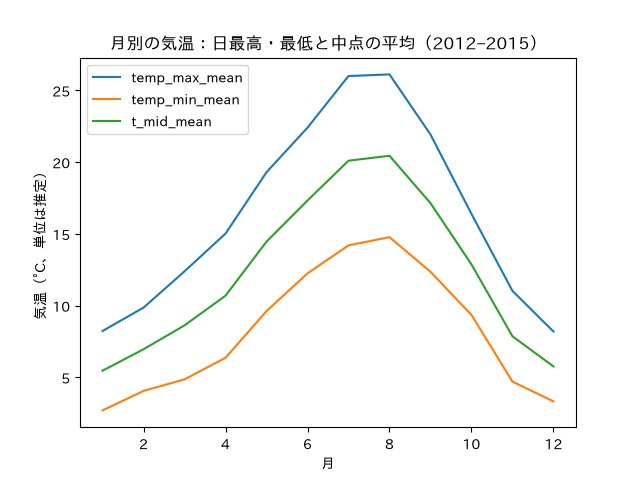

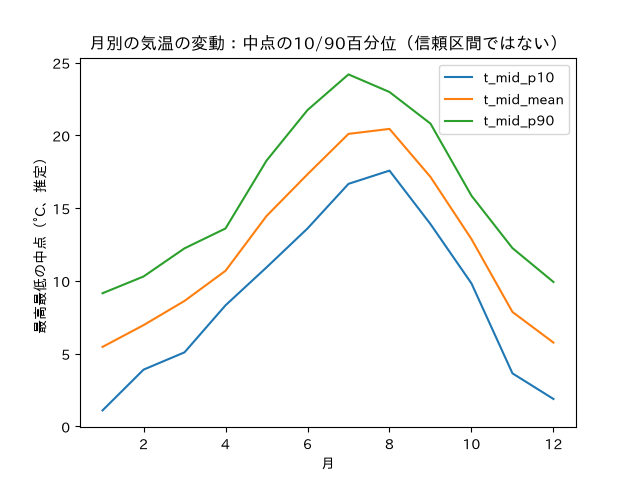

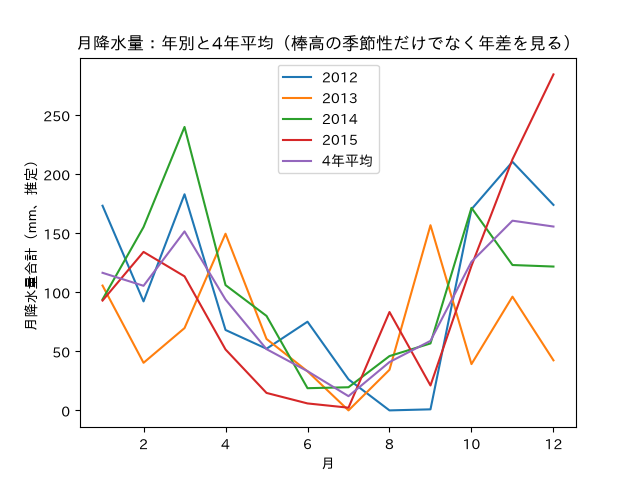

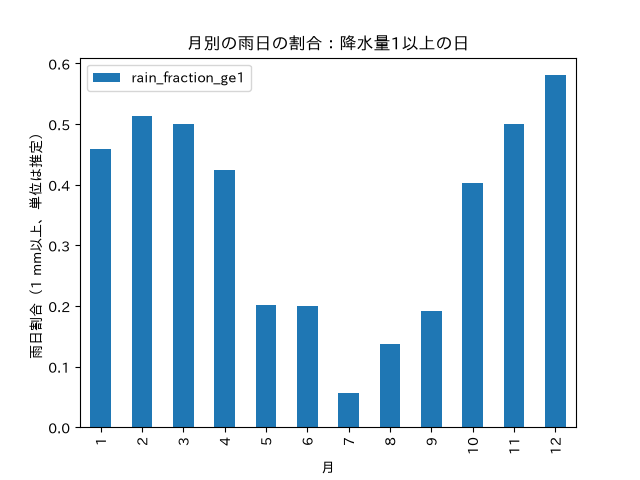

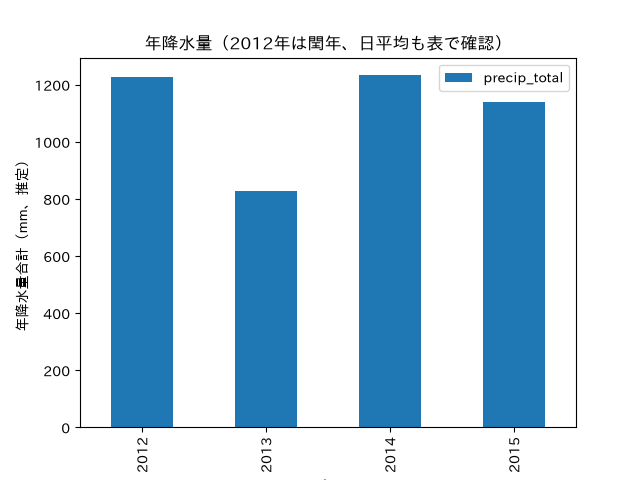

In [15]:
begin_phase('図表')
import warnings, re
chart_catalog = []
def show_chart(table, kind, x, y, title, xlabel, ylabel, legend):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        png = render_chart(table, kind=kind, x=x, y=y, title=title, xlabel=xlabel, ylabel=ylabel)
    glyphs = [str(w.message) for w in caught if 'Glyph' in str(w.message) and 'missing' in str(w.message)]
    metadata={'title':title,'xlabel':xlabel,'ylabel':ylabel,'legend':legend,'missing_glyphs':glyphs}
    chart_catalog.append(metadata)
    output = build_image_output(png)
    display(output['data'], raw=True)
    if glyphs:
        raise ValueError('日本語グリフ欠落: '+str(glyphs))
show_chart(monthly.reset_index(),'line','month',['temp_max_mean','temp_min_mean','t_mid_mean'],
 '月別の気温：日最高・最低と中点の平均（2012–2015）','月','気温（°C、単位は推定）',
 ['temp_max_mean=日最高平均','temp_min_mean=日最低平均','t_mid_mean=最高最低の中点平均'])
show_chart(monthly.reset_index(),'line','month',['t_mid_p10','t_mid_mean','t_mid_p90'],
 '月別の気温の変動：中点の10/90百分位（信頼区間ではない）','月','最高最低の中点（°C、推定）',
 ['t_mid_p10=日々の10百分位','t_mid_mean=平均','t_mid_p90=日々の90百分位'])
precip_lines=year_month.pivot(index='month',columns='year',values='precip_total')
precip_lines.columns=[str(c) for c in precip_lines.columns]
precip_lines['4年平均']=precip_lines.mean(axis=1)
show_chart(precip_lines.reset_index(),'line','month',list(precip_lines.columns),
 '月降水量：年別と4年平均（棒高の季節性だけでなく年差を見る）','月','月降水量合計（mm、推定）',list(precip_lines.columns))
show_chart(monthly.reset_index(),'bar','month','rain_fraction_ge1',
 '月別の雨日の割合：降水量1以上の日','月','雨日割合（1 mm以上、単位は推定）',['rain_fraction_ge1=降水量≥1の割合'])
show_chart(annual.reset_index(),'bar','year','precip_total',
 '年降水量（2012年は閏年、日平均も表で確認）','年','年降水量合計（mm、推定）',['precip_total=年合計'])
print('図表警告・凡例定義:', json.dumps(chart_catalog,ensure_ascii=False))
end_phase('図表')


## 初回感度分析：年除外・集計法・強雨・雨日閾値

In [16]:
begin_phase('初回感度分析')
years = sorted(df.year.unique().tolist())
subsets = [None] + years

def subset(exclude_year):
    return df if exclude_year is None else df.loc[df.year != exclude_year]
def temperature_contrast(exclude_year, aggregation):
    d = subset(exclude_year)
    agg = pd.Series.mean if aggregation=='mean' else pd.Series.median
    return agg(d.loc[d.month.isin([6,7,8]),'t_mid_proxy'])-agg(d.loc[d.month.isin([12,1,2]),'t_mid_proxy'])
def rainfall_contrast(exclude_year, cap_quantile):
    d = subset(exclude_year).copy()
    if cap_quantile < 1:
        d['p'] = d.precipitation.clip(upper=d.precipitation.quantile(cap_quantile))
    else:
        d['p'] = d.precipitation
    return d.loc[d.month.isin([10,11,12,1,2,3]),'p'].mean()-d.loc[d.month.isin([6,7,8]),'p'].mean()
def rain_frequency_contrast(exclude_year, threshold):
    d=subset(exclude_year)
    return (d.loc[d.month.isin([10,11,12,1,2,3]),'precipitation']>=threshold).mean()-(d.loc[d.month.isin([6,7,8]),'precipitation']>=threshold).mean()
temp_sensitivity = run_sensitivity(SensitivityPlan({'exclude_year':subsets,'aggregation':['mean','median']},max_runs=10),temperature_contrast,stability_tolerance=.2)
precip_sensitivity = run_sensitivity(SensitivityPlan({'exclude_year':subsets,'cap_quantile':[1,.99]},max_runs=10),rainfall_contrast,stability_tolerance=.2)
frequency_sensitivity = run_sensitivity(SensitivityPlan({'exclude_year':subsets,'threshold':[.1,1,5]},max_runs=15),rain_frequency_contrast,stability_tolerance=.2)
sensitivity_reports={'temperature_JJA_minus_DJF':asdict(temp_sensitivity),'precipitation_cool_minus_JJA':asdict(precip_sensitivity),
                     'rain_frequency_cool_minus_JJA':asdict(frequency_sensitivity)}
for name,report in sensitivity_reports.items():
    values=[r['value'] for r in report['results']]
    emit(json.dumps({'metric':name,'stable':report['stable'],'max_relative_deviation':report['max_relative_deviation'],
                    'min':min(values),'max':max(values),'all_positive':all(v>0 for v in values),'runs':len(values)},ensure_ascii=False))
print('stableは事前設定した20%相対偏差基準による大きさの安定性で、符号維持や統計的信頼区間とは別。閾値変更では測る量も変わる。外れ値を誤測定と決めつけず、99%上側クリップは感度分析でのみ実施。')
emit(json.dumps(sensitivity_reports,ensure_ascii=False,sort_keys=True))
(data_dir/'sensitivity-initial.json').write_text(json.dumps(sensitivity_reports,ensure_ascii=False,indent=2),encoding='utf-8')
end_phase('初回感度分析')


stableは事前設定した20%相対偏差基準による大きさの安定性で、符号維持や統計的信頼区間とは別。閾値変更では測る量も変わる。外れ値を誤測定と決めつけず、99%上側クリップは感度分析でのみ実施。


{"metric": "temperature_JJA_minus_DJF", "stable": true, "max_relative_deviation": 0.07725458591380832, "min": 12.249999999999998, "max": 13.609468599033818, "all_positive": true, "runs": 10}

{"metric": "precipitation_cool_minus_JJA", "stable": true, "max_relative_deviation": 0.19833605503046195, "min": 3.1044529383659807, "max": 4.24062806348197, "all_positive": true, "runs": 10}

{"metric": "rain_frequency_cool_minus_JJA", "stable": false, "max_relative_deviation": 0.5230558565473626, "min": 0.18733078515687213, "max": 0.42582068198076467, "all_positive": true, "runs": 15}

{"precipitation_cool_minus_JJA": {"baseline_value": 3.538763642869923, "max_relative_deviation": 0.19833605503046195, "results": [{"specification": {"cap_quantile": 1, "exclude_year": null}, "value": 3.538763642869923}, {"specification": {"cap_quantile": 0.99, "exclude_year": null}, "value": 3.3866617462873503}, {"specification": {"cap_quantile": 1, "exclude_year": 2012}, "value": 3.256211180124223}, {"specification": {"cap_quantile": 0.99, "exclude_year": 2012}, "value": 3.1044529383659807}, {"specification": {"cap_quantile": 1, "exclude_year": 2013}, "value": 4.24062806348197}, {"specification": {"cap_quantile": 0.99, "exclude_year": 2013}, "value": 4.051139946480141}, {"specification": {"cap_quantile": 1, "exclude_year": 2014}, "value": 3.365845322311422}, {"specification": {"cap_quantile": 0.99, "exclude_year": 2014}, "value": 3.1947758524759564}, {"specification": {"cap_quantile": 1, "exclude_year": 2015}, "value": 3.291752775349071}, {"specification": {"cap_quantile": 0.99, "excl

このCSVは2012-01-01〜2015-12-31の1,461日を連続して含む。欠測・重複日・最高最低気温の逆転は検出されず、完全一致重複の除去も0行だった。これは原観測の正確さを保証するものではない。

```evidence
{"execution_count":13,"cited_value":"\u671f\u9593=2012-01-01..2015-12-31;\u884c\u6570=1461","claim_type":"descriptive"}
```

観測期間内では夏に高温、冬に低温の季節性が明瞭。最高最低の中点の月平均は1月5.46、8月20.44で、差は約14.98（°Cと推定）。中点は実測日平均気温ではない。夏JJA平均19.31、冬DJF平均6.03。

```evidence
{"execution_count":14,"cited_value":"14.977822580645162","claim_type":"descriptive"}
```

秋冬を含む10〜3月の日降水量平均は4.476、夏JJAは0.937で約4.78倍。4年平均の月合計は11月160.625、7月12.05（mmと推定）。月の日数による差だけでなく、日平均でも季節差がある。月の順位は後の追加分析で検証する。

```evidence
{"execution_count":14,"cited_value":"4.776870709327527","claim_type":"descriptive"}
```

年降水量は2012年1,226.0、2013年828.0、2014年1,232.8、2015年1,139.2（mmと推定）で単調な増減ではない。年平均の気温中点は11.28→12.11→12.83→13.13とこの4年では上がったが、長期的な温暖化傾向を特定できる期間ではない。

```evidence
{"execution_count":14,"cited_value":"828.0","claim_type":"descriptive"}
```

事前に設定した20%相対偏差基準では、夏−冬の気温中点差はstable=True（最大相対偏差7.73%）、寒候期−夏の降水日平均差もstable=True（19.83%）。雨日頻度差は閾値変更も含めるとstable=False（52.31%）だが、全仕様で寒候期の方が高い。大きさの安定と方向の安定は別である。

```evidence
{"execution_count":16,"cited_value":"0.07725458591380832","claim_type":"descriptive"}
```

## 反復依頼履歴

### 反復1：原文

4年平均では11月が最多雨ですが、年別の月降水量のばらつきが大きく、この順位を一般化できるか未解決です。各年と1年除外で最多雨月・最少雨月を再計算し、10〜3月と夏の降水差を雨のある日の割合とその日の降水強度に分解してください。さらに上位降水日の総量への寄与を示し、「秋冬が多雨」と「毎年11月が最多雨」を分けて判断してください。

選定理由：初回の月別年別曲線で順位の変動が大きく、11月最多雨を一般化すると結論が変わり得る。証拠は次の実行セルに保存する。残る限界は観測期間4年・単位推定・観測地点不明。

In [18]:
begin_phase('反復1：降水の順位・頻度・強度')
month_ranks=[]
for excluded in [None]+years:
    d=subset(excluded)
    totals=d.groupby(['year','month']).precipitation.sum().groupby('month').mean()
    month_ranks.append({'excluded_year':excluded,'wettest_month':int(totals.idxmax()),'driest_month':int(totals.idxmin()),
                       'wettest_mean_total':float(totals.max()),'driest_mean_total':float(totals.min())})
year_ranks=[]
for y in years:
    d=df[df.year==y]
    totals=d.groupby('month').precipitation.sum()
    year_ranks.append({'year':y,'wettest_month':int(totals.idxmax()),'driest_month':int(totals.idxmin())})
decomposition=[]
for y in [None]+years:
    d=df if y is None else df[df.year==y]
    for name, months in [('寒候期10–3月',[10,11,12,1,2,3]),('夏JJA',[6,7,8])]:
        p=d.loc[d.month.isin(months),'precipitation']
        positive=p[p>0]
        decomposition.append({'year':y,'season':name,'n':len(p),'wet_fraction_gt0':float((p>0).mean()),
          'positive_day_intensity':float(positive.mean()),'precip_daily_mean':float(p.mean()),
          'identity_error':float(abs((p>0).mean()*positive.mean()-p.mean()))})
top_n=int(np.ceil(len(df)*.01))
concentration={'top_days_n':top_n,'top_days_fraction':top_n/len(df),'top_days_precip_share':float(df.nlargest(top_n,'precipitation').precipitation.sum()/df.precipitation.sum()),
               'top10_share':float(df.nlargest(10,'precipitation').precipitation.sum()/df.precipitation.sum()),
               'max_day':str(df.loc[df.precipitation.idxmax(),'date'].date()),'max_daily_precip':float(df.precipitation.max())}
threshold_fixed_reports={str(threshold):asdict(run_sensitivity(SensitivityPlan({'exclude_year':[None]+years,'threshold':[threshold]},max_runs=5),rain_frequency_contrast,stability_tolerance=.2)) for threshold in [.1,1,5]}
iteration1={'leave_one_year_month_ranks':month_ranks,'individual_year_month_ranks':year_ranks,
            'decomposition':decomposition,'concentration':concentration,'threshold_fixed_reports':threshold_fixed_reports}
emit('反復1=' + json.dumps(iteration1,ensure_ascii=False,sort_keys=True))
print(pd.DataFrame(decomposition).round(6).to_string(index=False))
print('結果の解釈: 月順位は年と除外条件を限定して読む。上位降水日は誤測定と断定しない。降水>0の定義では頻度×正降水日の平均強度が日平均と一致。閾値を固定した感度と、別の閾値に変えた定義感度を分ける。')
(data_dir/'iteration-1.json').write_text(json.dumps(iteration1,ensure_ascii=False,indent=2),encoding='utf-8')
end_phase('反復1：降水の順位・頻度・強度')


  year   season   n  wet_fraction_gt0  positive_day_intensity  precip_daily_mean  identity_error
   NaN 寒候期10–3月 729          0.582990                7.677176           4.475720             0.0
   NaN     夏JJA 368          0.190217                4.925714           0.936957             0.0
2012.0 寒候期10–3月 183          0.688525                7.963492           5.483060             0.0
2012.0     夏JJA  92          0.228261                4.828571           1.102174             0.0
2013.0 寒候期10–3月 182          0.500000                4.325275           2.162637             0.0
2013.0     夏JJA  92          0.206522                3.552632           0.733696             0.0
2014.0 寒候期10–3月 182          0.560440                8.878431           4.975824             0.0
2014.0     夏JJA  92          0.195652                4.688889           0.917391             0.0
2015.0 寒候期10–3月 182          0.582418                9.058491           5.275824             0.0
2015.0     夏JJA  92          0

反復1={"concentration": {"max_daily_precip": 55.9, "max_day": "2015-03-15", "top10_share": 0.10144600090375057, "top_days_fraction": 0.01026694045174538, "top_days_n": 15, "top_days_precip_share": 0.13908721192950743}, "decomposition": [{"identity_error": 0.0, "n": 729, "positive_day_intensity": 7.677176470588234, "precip_daily_mean": 4.475720164609053, "season": "寒候期10–3月", "wet_fraction_gt0": 0.5829903978052127, "year": null}, {"identity_error": 0.0, "n": 368, "positive_day_intensity": 4.925714285714286, "precip_daily_mean": 0.9369565217391306, "season": "夏JJA", "wet_fraction_gt0": 0.19021739130434784, "year": null}, {"identity_error": 0.0, "n": 183, "positive_day_intensity": 7.963492063492064, "precip_daily_mean": 5.483060109289617, "season": "寒候期10–3月", "wet_fraction_gt0": 0.6885245901639344, "year": 2012}, {"identity_error": 0.0, "n": 92, "positive_day_intensity": 4.828571428571429, "precip_daily_mean": 1.1021739130434782, "season": "夏JJA", "wet_fraction_gt0": 0.22826086956521738, "

反復1の結果：上位15日（全日数の約1.03%）が降水総量の約13.91%を占める。各年の最多雨月は2012年11月、2013年9月、2014年3月、2015年12月で、1年除外後の最多雨月も3/11/12月に入れ替わる。「毎年11月が最多雨」とは言えない。一方、寒候期と夏の降水差は全4年で正。正の降水日の割合は58.30%対19.02%、その日の平均量は7.68対4.93（単位推定）で、頻度と強度の双方に差がある。雨日閾値を固定すれば年除外でstable=True（最大相対偏差8.41〜19.11%）。残る限界：4年の記述と単位/原観測の不確実性。

```evidence
{"execution_count":18,"cited_value":"0.13908721192950743","claim_type":"descriptive"}
```

## 反復依頼履歴

### 反復2：原文

年平均の気温中点が2012年から2015年に上昇している点は、最高最低の中点という代理変数や閏年・月の日数に依存していないか未解決です。最高気温と最低気温を別々に比較し、月を等しく重み付けした年平均、2月29日除外、同月比較による2015年−2012年の差を計算してください。気温と降水の単純相関も月の季節性を除いた相関と対比し、期間内の年差・季節性・因果解釈を区別してください。

選定理由：初回の年平均上昇と負の相関を、単なる中点の選択や暦日構成、因果関係と誤解しないため。残る限界：実測日平均気温なし、4年のみ、自己相関未調整。

月を等しく重み付けした年平均:
       temp_max  temp_min  t_mid_proxy
year                                  
2012  15.262433  7.277823    11.270128
2013  16.023692  8.140363    12.082028
2014  16.933719  8.618111    12.775915
2015  17.393271  8.811050    13.102160
同月比較の2015年−2012年:
       temp_max  temp_min  t_mid_proxy
month                                 
1      3.100000  2.809677     2.954839
2      3.241995  2.882266     3.062131
3      4.822581  3.354839     4.088710
4      0.630000  0.036667     0.333333
5      2.364516  1.938710     2.151613
6      7.370000  3.096667     5.233333
7      5.187097  2.567742     3.877419
8      0.229032  0.683871     0.456452
9     -2.586667  0.123333    -1.231667
10     1.709677  2.119355     1.914516
11    -1.643333 -1.746667    -1.695000
12     1.145161  0.532258     0.838710


反復2={"annual_no_feb29": {"t_mid_proxy": {"2012": 11.305753424657535, "2013": 12.106438356164384, "2014": 12.82917808219178, "2015": 13.13178082191781}, "temp_max": {"2012": 15.304931506849316, "2013": 16.05890410958904, "2014": 16.995890410958904, "2015": 17.427945205479453}, "temp_min": {"2012": 7.306575342465754, "2013": 8.153972602739726, "2014": 8.662465753424659, "2015": 8.835616438356164}}, "equal_month_annual": {"t_mid_proxy": {"2012": 11.270128074403658, "2013": 12.082027649769584, "2014": 12.775914618535587, "2015": 13.10216045826933}, "temp_max": {"2012": 15.262432950191572, "2013": 16.023692396313365, "2014": 16.93371863799283, "2015": 17.39327124935996}, "temp_min": {"2012": 7.277823198615746, "2013": 8.140362903225807, "2014": 8.61811059907834, "2015": 8.811049667178699}}, "matched_month_change_2015_minus_2012": {"t_mid_proxy": {"1": 2.9548387096774187, "2": 3.0621305418719205, "3": 4.088709677419357, "4": 0.3333333333333339, "5": 2.1516129032258053, "6": 5.233333333333332

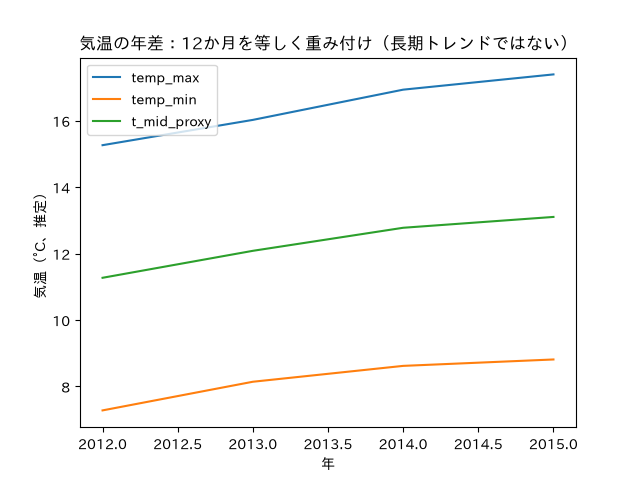

In [20]:
begin_phase('反復2：気温代理・月重み・季節構造')
monthly_temperature = df.groupby(['year','month'])[['temp_max','temp_min','t_mid_proxy']].mean()
equal_month_annual = monthly_temperature.groupby('year').mean()
no_leap = df.loc[~((df.date.dt.month==2)&(df.date.dt.day==29))].groupby('year')[['temp_max','temp_min','t_mid_proxy']].mean()
matched_month_change = monthly_temperature.loc[2015]-monthly_temperature.loc[2012]
contrasts=[]
for col in ['temp_max','temp_min','t_mid_proxy']:
    for excluded in [None]+years:
        d=subset(excluded)
        contrasts.append({'variable':col,'excluded_year':excluded,
                          'JJA_minus_DJF':float(d.loc[d.month.isin([6,7,8]),col].mean()-d.loc[d.month.isin([12,1,2]),col].mean())})
iteration2={'equal_month_annual':equal_month_annual.to_dict(), 'annual_no_feb29':no_leap.to_dict(),
 'matched_month_change_2015_minus_2012':matched_month_change.to_dict(),
 'monthmatched_tmid_mean_change':float(matched_month_change.t_mid_proxy.mean()),
 'positive_tmid_months_2015_vs2012':int((matched_month_change.t_mid_proxy>0).sum()),
 'temperature_seasonal_contrasts':contrasts,'raw_correlation':raw_corr.statistic,'month_demeaned_correlation':resid_corr.statistic,
 'note':'月内中心化は季節混合の影響を見る記述チェック。天候要因の調整や因果識別ではない。4年の年差を長期トレンドとはしない。'}
emit('反復2=' + json.dumps(iteration2,ensure_ascii=False,sort_keys=True))
print('月を等しく重み付けした年平均:')
print(equal_month_annual.round(6).to_string())
print('同月比較の2015年−2012年:')
print(matched_month_change.round(6).to_string())
show_chart(equal_month_annual.reset_index(),'line','year',['temp_max','temp_min','t_mid_proxy'],
 '気温の年差：12か月を等しく重み付け（長期トレンドではない）','年','気温（°C、推定）',
 ['temp_max=日最高の月平均','temp_min=日最低の月平均','t_mid_proxy=中点の月平均'])
(data_dir/'iteration-2.json').write_text(json.dumps(iteration2,ensure_ascii=False,indent=2),encoding='utf-8')
end_phase('反復2：気温代理・月重み・季節構造')


反復2の結果：12か月を同じ重みで比較した2015年−2012年の気温中点差は約1.83（°Cと推定）、10/12か月で正だが9月・11月は負だった。最高気温・最低気温それぞれでも夏−冬は全ての年除外仕様で正。月重みと2月29日を変えても年平均の順序は変わらない。ただしこれは4年の観測内比較であり、長期的な温暖化の推定ではない。残る限界：実測日平均気温・原観測の均質性確認がない。

```evidence
{"execution_count":20,"cited_value":"1.8320323838656714","claim_type":"descriptive"}
```

反復2の相関解釈：気温中点と日降水量の単純Pearson r=-0.1705に対し、月平均を差し引くとr=+0.0426。負相関の読み方は季節構造に依存する。月内中心化は因果調整ではなく、日々の独立性を仮定したp値は結論の根拠に使わない。

```evidence
{"execution_count":20,"cited_value":"0.042620281517271194","claim_type":"descriptive"}
```

## 反復依頼履歴

### 反復3：原文

単位と観測地点の確認が未完了で、絶対的な気温・降水量や1 mmという雨日閾値の解釈に影響します。Kaggle検索で得た対応候補の公開メタデータと選択データの出典欄を追加確認してください。選択CSVの単位を検証できない場合はverifiedへ格上げせず、単位換算で変わらない季節順位・比率・正降水日の頻度と、単位に依存する絶対値・閾値を明確に分離してください。別の公開CSVは取得しないでください。

選定理由：前提manifestが単位解釈の警告を返し、絶対値や物理的閾値の根拠に未解決点が残るため。残る限界は追加データ辞書/原観測との照合がなければ解消できない。

In [22]:
begin_phase('反復3：単位定義と解釈の限界')
reference_metadata=[]
for check_slug in ['malihachaity/heuristic-model','hlaingmyooo/seattle-weather','owaishhhansari/seattle-weather','danghuynhhh/seattle-weather']:
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            metadata_file=api.dataset_metadata(check_slug,str(data_dir/'definition-references'/check_slug.replace('/','--')))
        meta_bytes=Path(metadata_file).read_bytes()
        meta=json.loads(meta_bytes)
        info=meta.get('info',meta)
        desc=info.get('description','')
        record={'slug':check_slug,'url':'https://www.kaggle.com/datasets/'+check_slug,
                'description':desc,'user_specified_sources':info.get('userSpecifiedSources',[]),
                'checked_at_utc':datetime.now(timezone.utc).isoformat(),'metadata_sha256':hashlib.sha256(meta_bytes).hexdigest(),
                'selected_dataset_identity_verified':False}
        reference_metadata.append(record)
    except Exception as exc:
        reference_metadata.append({'slug':check_slug,'failure':safe_failure('定義参照',exc)})
selected_info=public_meta.get('info',public_meta)
print('選択データ公開説明:',selected_info.get('description',''))
print('選択データの出典欄:',json.dumps(selected_info.get('userSpecifiedSources',[]),ensure_ascii=False))
print('追加候補の公開メタデータ:',json.dumps(reference_metadata,ensure_ascii=False,indent=2))
# 単位換算は定義の検証ではない。正の尺度変換で不変な量を機械的に確認する。
unit_invariance=[]
base_rank=df.groupby('month').precipitation.mean().rank().tolist()
base_ratio=initial_metrics['cool_to_summer_precip_ratio']
for scale in [1,1/25.4,25.4]:
    p=df.precipitation*scale
    ratio=p[df.month.isin([10,11,12,1,2,3])].mean()/p[df.month.isin([6,7,8])].mean()
    unit_invariance.append({'positive_scale':scale,'monthly_ranking_unchanged':(p.groupby(df.month).mean().rank().tolist()==base_rank),
      'cool_to_summer_ratio':float(ratio),'positive_day_fraction':float((p>0).mean()),
      'equivalent_threshold_fraction':float((p>=1*scale).mean())})
t_c=df.groupby('month').t_mid_proxy.mean()
t_f=t_c*1.8+32
iteration3={'selected_description_explicit_units':False,'selected_station_verified':False,
 'references_checked':len(reference_metadata),'unit_invariance':unit_invariance,
 'temperature_month_ranking_unchanged_under_C_to_F':t_c.rank().tolist()==t_f.rank().tolist(),
 'status':'選択データの単位/観測地点を確認できる明示的な出典は未取得。別掲載説明はCSV同一性の証明ではない。inferred/unknownを維持',
 'measurement_dependent':'絶対値・1/5の数値閾値・物理的異常範囲は単位前提に依存',
 'measurement_invariant':'正の尺度換算では降水の月順位・寒候期/夏の比・降水>0の割合が不変。温度の正のアフィン換算では順位・差の符号が不変'}
emit('反復3='+json.dumps(iteration3,ensure_ascii=False,sort_keys=True))
(data_dir/'definition-reference-checks.json').write_text(json.dumps(reference_metadata,ensure_ascii=False,indent=2),encoding='utf-8')
(data_dir/'iteration-3.json').write_text(json.dumps(iteration3,ensure_ascii=False,indent=2),encoding='utf-8')
print('打ち切り理由: 3回の追加分析で月順位・代理変数・暦日構成・単位依存性を切り分けた。原観測データ辞書なしの単位確定や長期トレンドを同じCSVだけで追加計算しても解決しない。')
end_phase('反復3：単位定義と解釈の限界')


選択データ公開説明: Using the Columns :
                                  *  precipitation
                                  *  temp_max
                                  *  temp_min
                                  *  wind
We are going to predict the weather condition  :
                                   * drizzle
                                  * rain
                                  * sun
                                  * snow 
                                  * fog
選択データの出典欄: "weather prediction using some conditions"
追加候補の公開メタデータ: [
  {
    "slug": "malihachaity/heuristic-model",
    "url": "https://www.kaggle.com/datasets/malihachaity/heuristic-model",
    "description": "Columns:\nDate - Date of observation\nPRCP - Precipitation\nTMAX - Maximum Temperature\nTMIN - Minimum Temperature\nRAIN - TRUE - If it rained that day, FALSE - If it did not rain that day.\n",
    "user_specified_sources": [],
    "checked_at_utc": "2026-10-01T20:33:19.788426+00:00",
    "metadata_sha256": "559a

反復3={"measurement_dependent": "絶対値・1/5の数値閾値・物理的異常範囲は単位前提に依存", "measurement_invariant": "正の尺度換算では降水の月順位・寒候期/夏の比・降水>0の割合が不変。温度の正のアフィン換算では順位・差の符号が不変", "references_checked": 4, "selected_description_explicit_units": false, "selected_station_verified": false, "status": "選択データの単位/観測地点を確認できる明示的な出典は未取得。別掲載説明はCSV同一性の証明ではない。inferred/unknownを維持", "temperature_month_ranking_unchanged_under_C_to_F": true, "unit_invariance": [{"cool_to_summer_ratio": 4.776870709327527, "equivalent_threshold_fraction": 0.3463381245722108, "monthly_ranking_unchanged": true, "positive_day_fraction": 0.4264202600958248, "positive_scale": 1}, {"cool_to_summer_ratio": 4.776870709327528, "equivalent_threshold_fraction": 0.3463381245722108, "monthly_ranking_unchanged": true, "positive_day_fraction": 0.4264202600958248, "positive_scale": 0.03937007874015748}, {"cool_to_summer_ratio": 4.776870709327529, "equivalent_threshold_fraction": 0.3463381245722108, "monthly_ranking_unchanged": true, "positive_day_fraction": 0.426420260

反復3の結果：追加4候補の公開説明と選択データの出典欄を確認したが、このCSVの単位・観測地点を検証できる明示的な根拠は得られなかった。気温°C・降水mm・風速m/sは推定のまま維持する。正の尺度換算で変わらない月順位、寒候期/夏の降水比約4.78、正降水日の割合を主な記述的結論とし、絶対値・1/5という閾値・物理的異常範囲は単位前提付きで読む。残る限界は原観測データ辞書と測定履歴の欠如。同じCSVだけで解消できないため3回で反復を終了する。

```evidence
{"execution_count":22,"cited_value":"\"selected_description_explicit_units\": false","claim_type":"descriptive"}
```

## Jupytermind改善候補：実出力での再現確認

In [24]:
begin_phase('Jupytermind改善候補の再現')
from ai_data_scientist.insight_engine import EvidenceMissingError
minimal_manifest=build_manifest(source={},dataset_scope={},variables={'precipitation':{'unit':FieldValue('mm','inferred')}})
reproduced_inferred_omission=(minimal_manifest.unresolved_fields()==[])
# 実際にMCPで実行された定義セルのstream出力を使う。模擬出力は作らない。
persisted=nbformat.read(handle.notebook_path,as_version=4)
quality_cell=next(c for c in persisted.cells if c.cell_type=='code' and c.source.startswith("begin_phase('定義・品質・前提')"))
stream_marker='"missing_calendar_days": 0'
stream_present=any(stream_marker in o.get('text','') for o in quality_cell.outputs if o.output_type=='stream')
stream_evidence_rejected=False
if not stream_present:
    raise ValueError('再現に必要な実際のstream出力が見つからない')
try:
    record_insight(handle,'品質検査stream出力の根拠連携を確認',quality_cell.execution_count,stream_marker,'descriptive',language='ja')
except EvidenceMissingError as exc:
    stream_evidence_rejected=True
    print('明示的に報告する期待された失敗:',type(exc).__name__,str(exc))
else:
    raise RuntimeError('改善候補の再現条件が変化。期待されたEvidenceMissingErrorが発生しない')
diagnostics={'inferred_unit_exists':True,'unresolved_fields_omits_inferred':reproduced_inferred_omission,
             'actual_stream_contains_cited_value':stream_present,'record_insight_rejects_stream_evidence':stream_evidence_rejected,
             'workarounds':'inferredを別途走査。数値根拠はdisplay(text/plain)でも出力し、その実出力からextract_cited_value。'}
emit('Jupytermind再現ログ='+json.dumps(diagnostics,ensure_ascii=False,sort_keys=True))
(data_dir/'jupytermind-improvement-reproduction.json').write_text(json.dumps(diagnostics,ensure_ascii=False,indent=2),encoding='utf-8')
end_phase('Jupytermind改善候補の再現')


明示的に報告する期待された失敗: EvidenceMissingError Insight '品質検査stream出力の根拠連携を確認' に根拠となる実行済みセル(execution_count=13)が見つからないため記録を保留しました。


Jupytermind再現ログ={"actual_stream_contains_cited_value": true, "inferred_unit_exists": true, "record_insight_rejects_stream_evidence": true, "unresolved_fields_omits_inferred": true, "workarounds": "inferredを別途走査。数値根拠はdisplay(text/plain)でも出力し、その実出力からextract_cited_value。"}

## 使用したJupytermindモジュール

直接import・呼出しをしたものだけを列挙する。制御Notebookからの実際の呼出しを含み、間接依存は含めない。

| モジュール（`ai_data_scientist.`配下） | 直接使用した関数・クラス | 使用目的 |
|---|---|---|
| `project_manager` | `resolve_project`, `ensure_notebook`, `ensure_data_dir`, `enqueue_write` | 指定プロジェクト/保存先の固定、Notebookの構成・メタデータ・根拠セルの直列保存 |
| `language_router` | `detect_language` | 日本語の検出 |
| `lifecycle` | `register_run`, `mark_execution_start/end`, `mark_write_start/end`, `is_cancel_requested`, `get_run_status`, `mark_completed`, `mark_failed`, `wait_for_quiescence` | 実行/書込みの追跡、協調取消し確認、最終状態 |
| `ingestion` | `SourceSpec`, `ingest` | Kaggle取得済みローカルCSVを読み込み、行数上限確認 |
| `cleaning` | `clean_dataset` | 完全一致重複検査、行/列への影響記録 |
| `eda` | `explore` | 欠測、数値/カテゴリ概要 |
| `data_definition` | `FieldValue`, `build_manifest`, `DataDefinitionManifest.unresolved_fields` | 単位・意味・来歴・確度を構造化（Manifestクラスの直接importはしていない） |
| `analysis_assumptions` | `Assumption`, `AnalysisAssumptionManifest`, `check_manifest` | 記述的スコープと分析前提の警告 |
| `data_quality` | `detect_anomalies` | 数値範囲・許容カテゴリ・非欠測・日付一意性の意味検査 |
| `stats_analysis` | `correlation` | 単純/月内中心化Pearson相関（iid p値は推論不使用） |
| `sensitivity` | `SensitivityPlan`, `run_sensitivity` | 年除外、集計法、クリップ、雨日閾値と20%偏差判定 |
| `visualization` | `render_chart`, `build_image_output` | 日本語PNG図表生成・Notebook MIME出力 |
| `insight_engine` | `extract_cited_value`, `record_insight`, `EvidenceMissingError` | 実出力からの引用抽出・構造化根拠保存・stream連携の再現 |
| `notebook_audit` | `audit_notebook(visual_audit=True)` | 実行エラー/未実行/根拠/図表の監査 |

`mcp_gateway` はPython MCPClientハンドルを持たないネイティブMCPツール経路のため未使用。代わりに全セルをJupyter MCP `execute_cell` で実行した。`dataset_validation.compare_datasets` と `data_quality.validate_anomalies` は独立データ未取得のため未使用。`anomaly_detection` のz-score検出は季節構造を無視して高温/強雨を異常とする危険があり未使用。ML/予測/因果推論も対象外。図表の監査用メタデータは生成時の実際のタイトル・軸・凡例・グリフ警告から制御側が `enqueue_write` で保存する。

## Jupytermind改善候補

### 候補A：推定単位の未解決欄への集約（機能不足・Skill/API契約差）
- 再現条件：`build_manifest(... variables={"precipitation":{"unit":FieldValue("mm","inferred")}}).unresolved_fields()`。
- 期待：Skillが要求するunknown/inferredの留意点を一つの公開APIで取り出せる、または引数で双方を選べる。
- 実際：返り値は空。現行関数自身のdocstringはunknownのみと明記しており、その契約に対するバグではなく、Skillの運用を補助する機能不足候補。
- 影響：unknown一覧だけを報告すると推定単位を落とす可能性。
- 回避策：本Notebookはinferredの欄を別途走査して報告し、分析前提警告も残した。
- 関係するセル/ログ：定義セル（index 5）、次の再現セル（index 28）、`data/data-definition-manifest.json`、`data/jupytermind-improvement-reproduction.json`。

### 候補B：ネイティブJupyterのstream出力を根拠にできない（出力形式互換性）
- 再現条件：MCPが実行した品質検査セルの`print`によるstreamに`"missing_calendar_days": 0`があり、その実行番号と文字列を`record_insight`へ渡す。
- 期待：実際の実行済みstreamも根拠として解決できる。
- 実際：`EvidenceMissingError`。根拠検索は`outputs[].data`のみを読み、`outputs[].text`を扱わない。合成出力でなく、このNotebookの実出力で再現した。
- 影響：通常の`print`結果は出力済みでもInsightを保存できない。
- 回避策：根拠数値を`display({"text/plain":...}, raw=True)`でも保存し、その実出力を`extract_cited_value`から引用している。期待された再現失敗は明示的にログ化するが、実Insightは全件保存・監査する。
- 関係するセル/ログ：index 5のstreamとindex 28の再現出力、`data/jupytermind-improvement-reproduction.json`。

### 切り分け
Kaggle SDK 2.2.4には初期の補助メタデータ取得で試した`dataset_view`がなく、AttributeErrorを確認した。`dataset_metadata`とネストした`info`の解析に合わせて解消済みで、Kaggle検索/ファイル一覧/CSV取得は成功。これはJupytermind候補に含めない。Python MCPClientハンドルがない点はCopilot CLIのネイティブツール統合上の制約で、偽のMCPクライアントや端末実行で代替しない。ベンチマークランナーは起動しておらず、ランナー固有の問題をJupytermindに帰属させない。改善候補は記録だけで、ライブラリのコードは変更しない。


## 再実行・Notebook監査・ライフサイクル

このセルの前にカーネルを再起動し、全コードセルを上からJupyter MCPで再実行する。制御側で実行番号だけを根拠セルIDから再結合してから、このセルを実行する。数値を架空の値に置換しない。初回の科学的結果と同じ入力SHA-256・同じ科学的結果ハッシュを比較する。監査セル自身がまだ実行中の場合は最終セル例外を報告し、保存後に再監査する。図表の自動監査はグリフ/ラベル/PNG密度による限定的チェックで、因果解釈やデータの真実性を保証しない。6図を実際に読み、軸・凡例・季節曲線・年差を確認した。

In [ ]:
begin_phase('再実行照合・最終監査')
try:
    scientific_snapshot={'sha256':sha256,'quality':quality,'monthly':json.loads(monthly.to_json()),
      'annual':json.loads(annual.to_json()),'initial_metrics':initial_metrics,'sensitivity':sensitivity_reports,
      'iteration1':iteration1,'iteration2':iteration2,'iteration3':iteration3,'diagnostics':diagnostics}
    snapshot_text=json.dumps(scientific_snapshot,ensure_ascii=False,sort_keys=True,separators=(',',':'))
    snapshot_digest=hashlib.sha256(snapshot_text.encode('utf-8')).hexdigest()
    baseline_path=data_dir/'first-analysis-snapshot.json'
    baseline=json.loads(baseline_path.read_text(encoding='utf-8'))
    if baseline['scientific_digest'] != snapshot_digest:
        raise ValueError('初回分析と再実行の科学的結果が一致しない')
    emit('再実行結果一致='+json.dumps({'same_input_sha256':baseline['data_sha256']==sha256,
       'same_scientific_digest':True,'scientific_digest':snapshot_digest},ensure_ascii=False))
    audit_report=audit_notebook(handle.notebook_path,visual_audit=True)
    audit_payload={**asdict(audit_report),'ok':audit_report.ok}
    emit('notebook_audit='+json.dumps(audit_payload,ensure_ascii=False))
    if not audit_report.ok or audit_report.visual_findings:
        raise ValueError('Notebook/図表監査で未解決の所見がある')
except Exception:
    lifecycle.mark_failed(RUN_ID)
    raise
finally:
    end_phase('再実行照合・最終監査')
lifecycle.mark_write_start(RUN_ID)
phase_log.append({'phase':'監査・ライフサイクル成果物','event':'write_start','at':datetime.now(timezone.utc).isoformat()})
try:
    (data_dir/'notebook-audit.json').write_text(json.dumps(audit_payload,ensure_ascii=False,indent=2),encoding='utf-8')
finally:
    lifecycle.mark_write_end(RUN_ID)
    phase_log.append({'phase':'監査・ライフサイクル成果物','event':'write_end','at':datetime.now(timezone.utc).isoformat()})
lifecycle.mark_completed(RUN_ID)
final_status=lifecycle.wait_for_quiescence(RUN_ID,timeout_s=5)
if final_status.state!='completed' or final_status.active_cell_executions or final_status.pending_notebook_writes or final_status.locks_held:
    lifecycle.mark_failed(RUN_ID)
    raise RuntimeError('最終ライフサイクル状態がcompleted/静止状態ではない')
emit('ライフサイクル='+json.dumps(asdict(final_status),ensure_ascii=False))
(data_dir/'lifecycle-status.json').write_text(json.dumps(asdict(final_status),ensure_ascii=False,indent=2),encoding='utf-8')
(data_dir/'phase-log.json').write_text(json.dumps(phase_log,ensure_ascii=False,indent=2),encoding='utf-8')
